In [3]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# sklearn
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import cross_val_score

# =========================
# Qiskit (compatibility-aware)
# =========================

from qiskit import QuantumCircuit
from qiskit.utils import algorithm_globals
from qiskit.circuit.library import EfficientSU2, ZZFeatureMap
from qiskit.algorithms.optimizers import SPSA, L_BFGS_B, COBYLA

try:
    from qiskit.circuit.library import zz_feature_map
except ImportError:
    zz_feature_map = None

try:
    from qiskit.primitives import StatevectorSampler

    def build_sampler(seed=None):
        return StatevectorSampler(seed=seed)
except ImportError:
    from qiskit.primitives import Sampler

    def build_sampler(seed=None):
        return Sampler()

from qiskit_machine_learning.algorithms import QSVC, NeuralNetworkClassifier, VQC
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.neural_networks import SamplerQNN

try:
    from qiskit_machine_learning.kernels import QuantumKernel
except ImportError:
    QuantumKernel = None

try:
    from qiskit_machine_learning.state_fidelities import ComputeUncompute
except ImportError:
    ComputeUncompute = None

from IPython.display import clear_output

import warnings
warnings.filterwarnings('ignore')


C:\Users\rkous_y3qdg3w\AppData\Local\Temp\ipykernel_29212\1876901895.py:29: DeprecationWarning: ``qiskit.algorithms`` has been migrated to an independent package: https://github.com/qiskit-community/qiskit-algorithms. The ``qiskit.algorithms`` import path is deprecated as of qiskit-terra 0.25.0 and will be removed no earlier than 3 months after the release date. Please run ``pip install qiskit_algorithms`` and use ``import qiskit_algorithms`` instead.
  from qiskit.algorithms.optimizers import SPSA, L_BFGS_B, COBYLA


In [4]:
import sys
print(sys.executable)



d:\PROJECT\kkkk\qml_env\Scripts\python.exe


In [5]:
data = pd.read_csv('Cleveland Dataset.csv')
df = data.copy()
selected_features = ['ca', 'cp', 'thal', 'exang', 'slope']


def build_shared_feature_map(feature_dimension):
    if zz_feature_map is not None:
        return zz_feature_map(
            feature_dimension=feature_dimension,
            reps=2,
            entanglement='linear'
        )
    return ZZFeatureMap(
        feature_dimension=feature_dimension,
        reps=2,
        entanglement='linear'
    )


def build_shared_ansatz(num_qubits):
    return EfficientSU2(num_qubits=num_qubits, reps=2)


def build_quantum_kernel(feature_map, seed=None):
    if ComputeUncompute is not None:
        fidelity = ComputeUncompute(sampler=build_sampler(seed))
        return FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelity)
    if FidelityQuantumKernel is not None:
        return FidelityQuantumKernel(feature_map=feature_map)
    return QuantumKernel(feature_map=feature_map)


print(df.head())


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [6]:
print(data.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [7]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Heart Disease Distribution

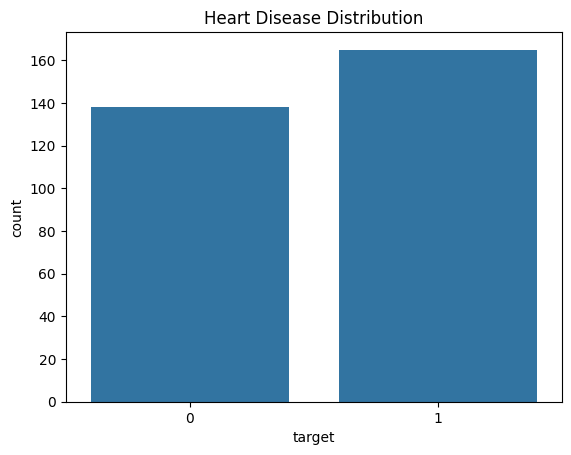

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target',data=data)
plt.title("Heart Disease Distribution")
plt.show()

## Feature Correlation Heatmap

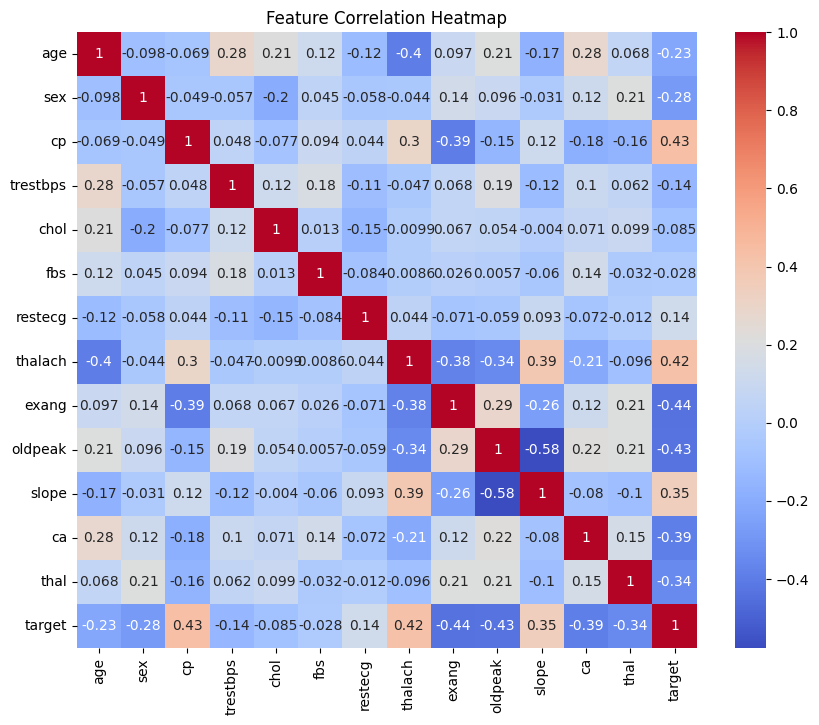

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

## Feature selection

In [10]:
from sklearn.feature_selection import RFE
from sklearn.svm import SVC

X = data.drop(['target'] ,axis="columns")
y = data['target']

estimator = SVC(kernel="linear")
selector = RFE(estimator, n_features_to_select=6, step=1)
selector = selector.fit(X, y)

In [11]:
from operator import itemgetter
features = X.columns.to_list()
for x, y in (sorted(zip(selector.ranking_ , features), key=itemgetter(0))):
    print(x, y)

1 sex
1 cp
1 exang
1 slope
1 ca
1 thal
2 oldpeak
3 restecg
4 fbs
5 thalach
6 trestbps
7 age
8 chol


<function matplotlib.pyplot.show(close=None, block=None)>

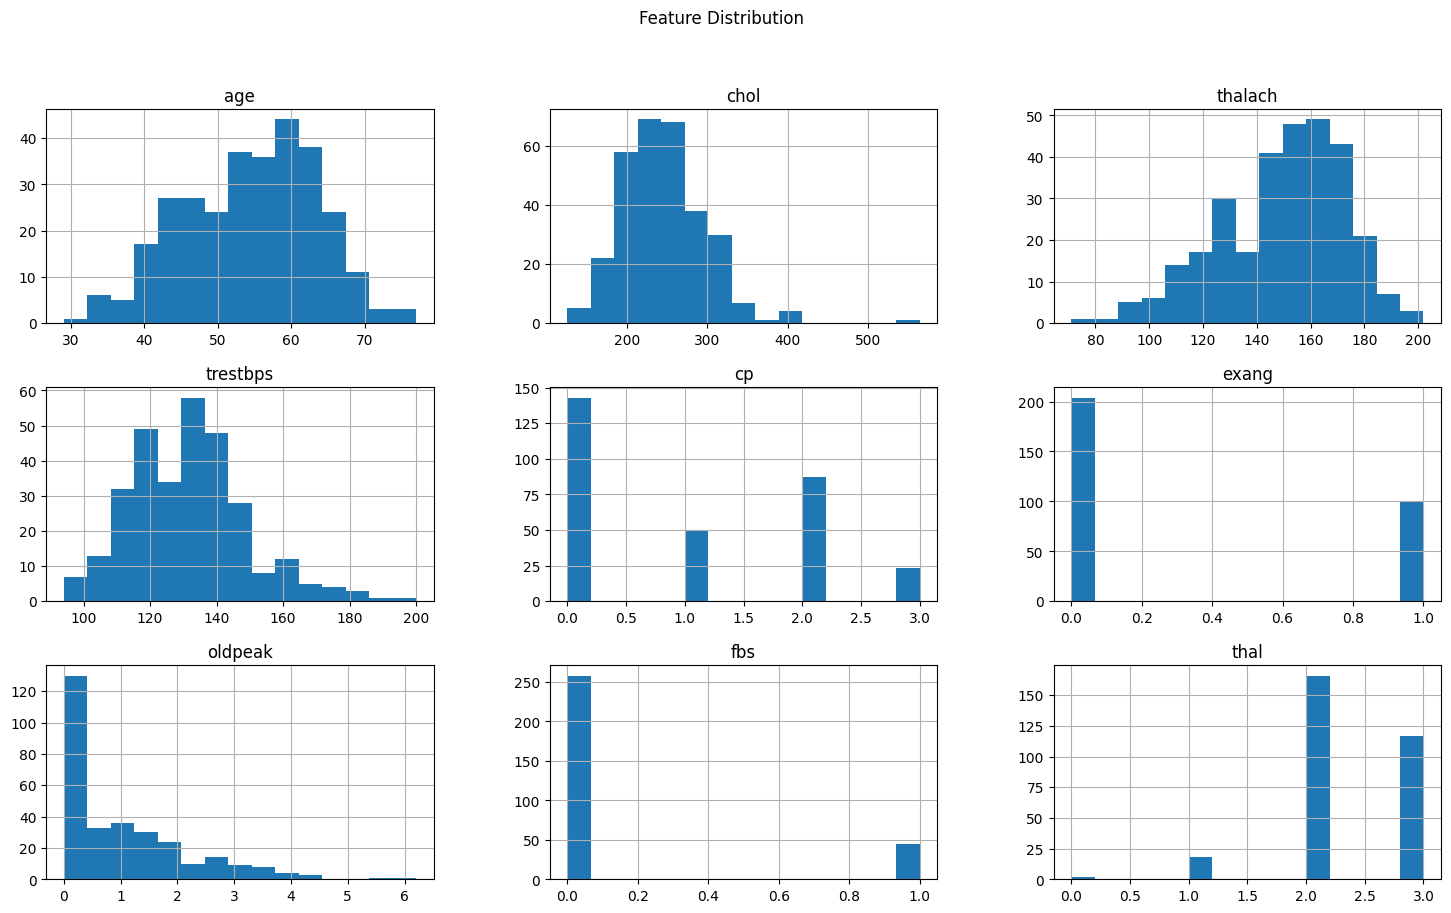

In [12]:
features =['age', 'chol', 'thalach','trestbps','cp','exang','oldpeak','fbs', 'thal']
data[features].hist(figsize=(18,10), bins=15)
plt.suptitle("Feature Distribution")
plt.show

In [13]:
corr_with_target=data.corr()['target'].sort_values(ascending=False)
print(corr_with_target)

target      1.000000
cp          0.433798
thalach     0.421741
slope       0.345877
restecg     0.137230
fbs        -0.028046
chol       -0.085239
trestbps   -0.144931
age        -0.225439
sex        -0.280937
thal       -0.344029
ca         -0.391724
oldpeak    -0.430696
exang      -0.436757
Name: target, dtype: float64


# Classical classifiers 

## SVM

In [14]:
# =========================
# Support vector machine (SVM)
# =========================

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


X = df[selected_features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Underfitted SVM
ClassifierSVM = SVC(
    kernel='rbf',
    C=0.1,
    gamma=0.5,
    class_weight='balanced'
)
ClassifierSVM.fit(X_train, y_train)
y_pred_svm = ClassifierSVM.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"Classical SVC Accuracy: {svm_accuracy*100:.2f}%")


Classical SVC Accuracy: 80.33%


### SVM performance

In [15]:
# classification report of SVM
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

expected_y  = y_test
predicted_y = ClassifierSVM.predict(X_test)

svm_acc = accuracy_score(expected_y, predicted_y)


# print accuracy, classification report and confusion matrix for svm classifier
print(f"Classical SVC Accuracy: {svm_acc*100:.2f}%")
print("Classification report: \n", metrics.classification_report(expected_y, predicted_y))
print("Confusion matrix: \n", metrics.confusion_matrix(expected_y, predicted_y))

Classical SVC Accuracy: 80.33%
Classification report: 
               precision    recall  f1-score   support

           0       0.74      0.90      0.81        29
           1       0.88      0.72      0.79        32

    accuracy                           0.80        61
   macro avg       0.81      0.81      0.80        61
weighted avg       0.82      0.80      0.80        61

Confusion matrix: 
 [[26  3]
 [ 9 23]]


### SVM--Confusion Matrix

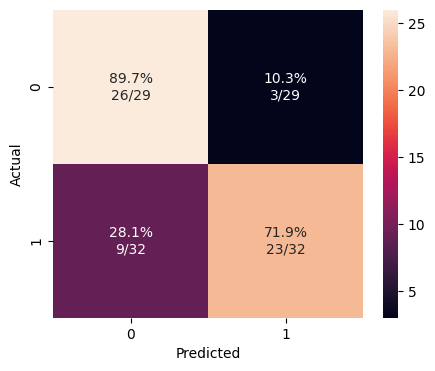

In [16]:
# confusion matrix of SVM
def cm_analysis(y_true, y_pred, labels, ymap=None, figsize=(5,4)): 
    if ymap is not None: 
        y_pred = [ymap[yi] for yi in y_pred] 
        y_true = [ymap[yi] for yi in y_true] 
        labels = [ymap[yi] for yi in labels]
def cm_analysis(y_true, y_pred, labels, ymap=None, figsize=(5,4)): 
    if ymap is not None: 
        y_pred = [ymap[yi] for yi in y_pred] 
        y_true = [ymap[yi] for yi in y_true] 
        labels = [ymap[yi] for yi in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels) 
    cm_sum = np.sum(cm, axis=1, keepdims=True) 
    cm_perc = cm / cm_sum.astype(float) * 100 

    annot = np.empty_like(cm).astype(str) 
    nrows, ncols = cm.shape 

    for i in range(nrows): 
        for j in range(ncols): 
            c = cm[i, j] 
            p = cm_perc[i, j] 
            s = cm_sum[i][0]

            if c == 0:
                annot[i, j] = '0.0%%\n0/%d' % s
            else:
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)

    cm = pd.DataFrame(cm, index=labels, columns=labels) 
    cm.index.name = 'Actual' 
    cm.columns.name = 'Predicted' 

    fig, ax = plt.subplots(figsize=figsize) 
    sns.heatmap(cm, annot=annot, fmt='', ax=ax) 

cm_analysis(y_test, predicted_y, labels=[0,1], ymap=None, figsize=(5,4)) 

### SVM--ROC Curve

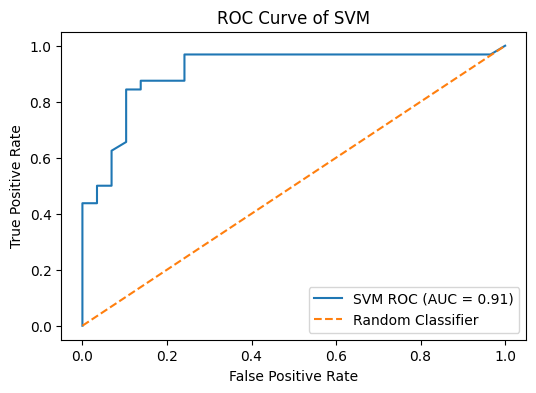

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get decision scores instead of class labels
svm_scores = ClassifierSVM.decision_function(X_test)

# ROC values
fper, tper, thresholds = roc_curve(expected_y, svm_scores)
roc_auc = auc(fper, tper)

# Plot ROC
plt.figure(figsize=(6,4))
plt.plot(fper, tper, label=f'SVM ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of SVM')
plt.legend()
plt.show()


## ANN

In [18]:
# Also known as classical QNN
X = df[selected_features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

model = MLPClassifier(max_iter=1000, random_state=5)
model = model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Classical ANN Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")


Classical ANN Accuracy: 85.25%


### ANN Performance

In [19]:
# classification report of ANN
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

expected_y  = y_test
predicted_y = model.predict(X_test) 

ann_acc = accuracy_score(expected_y, predicted_y)
print(f"Classical ANN Accuracy: {ann_acc*100:.2f}%")
 

# print classification report and confusion matrix for the classifier
print("Classification report: \n", metrics.classification_report(expected_y, predicted_y))
print("Confusion matrix: \n", metrics.confusion_matrix(expected_y, predicted_y))

Classical ANN Accuracy: 85.25%
Classification report: 
               precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

Confusion matrix: 
 [[25  4]
 [ 5 27]]


### ANN--Confusion Matrix

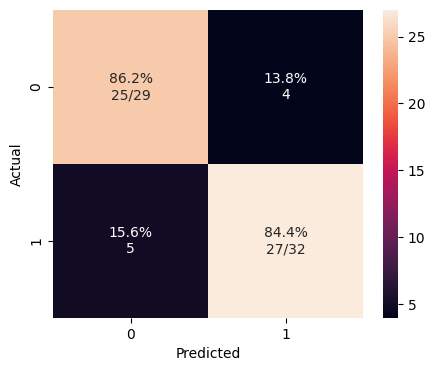

In [20]:
# confusion matrix of ANN
def cm_analysis(y_true, y_pred, labels, ymap=None, figsize=(5,4)):
    if ymap is not None:
        y_pred = [ymap[yi] for yi in y_pred]
        y_true = [ymap[yi] for yi in y_true]
        labels = [ymap[yi] for yi in labels]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_sum = np.sum(cm, axis=1, keepdims=True)
    cm_perc = cm / cm_sum.astype(float) * 100
    annot = np.empty_like(cm).astype(str)
    nrows, ncols = cm.shape
    for i in range(nrows):
        for j in range(ncols):
            c = cm[i, j]
            p = cm_perc[i, j]
            if i == j:
                s = cm_sum[i][0]
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)
            elif c == 0:
                annot[i, j] = ''
            else:
                annot[i, j] = '%.1f%%\n%d' % (p, c)
    cm = pd.DataFrame(cm, index=labels, columns=labels)
    cm.index.name = 'Actual'
    cm.columns.name = 'Predicted'
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm, annot=annot, fmt='', ax=ax)

cm_analysis(y_test, predicted_y, labels=[0,1], ymap=None, figsize=(5,4))


### ANN--ROC Curve

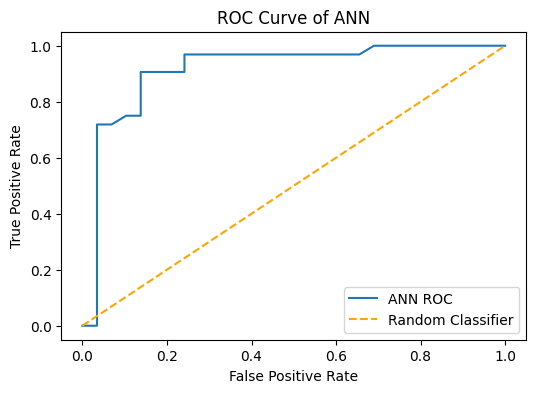

In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for positive class
y_prob = model.predict_proba(X_test)[:, 1]

# ROC values
fper, tper, thresholds = roc_curve(expected_y, y_prob)
roc_auc = auc(fper, tper)

# Plot ROC
plt.figure(figsize=(6,4))
plt.plot(fper, tper, label='ANN ROC ')
plt.plot([0, 1], [0, 1], linestyle='--',color='orange', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of ANN')
plt.legend()
plt.show()


# Quantum classifiers 

   ## QSVC

In [22]:
X = df[selected_features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

samples = np.append(X_train, X_test, axis=0)
minmax_scaler = MinMaxScaler((0, 1)).fit(samples)
X_train = minmax_scaler.transform(X_train)
X_test = minmax_scaler.transform(X_test)


In [23]:
# number of qubits is equal to the number of features
num_qubits = X_train.shape[1]
# regularization parameter
C = 1000


In [24]:
from qiskit.utils import algorithm_globals
from qiskit_machine_learning.algorithms import QSVC

algorithm_globals.random_seed = 12345

feature_map = build_shared_feature_map(num_qubits)
qkernel = build_quantum_kernel(feature_map, seed=algorithm_globals.random_seed)

qsvc = QSVC(quantum_kernel=qkernel, C=C)


In [25]:
# training
qsvc.fit(X_train,y_train)

# testing
qsvc_score = qsvc.score(X_test, y_test)
print(f"QSVC classification test score: {qsvc_score*100:.2f}%")


QSVC classification test score: 75.41%


### QSVC performance

In [26]:
# classification report of QSVC
expected_y  = y_test
predicted_y = qsvc.predict(X_test) 

# print classification report and confusion matrix for the classifier
print("Classification report: \n", metrics.classification_report(expected_y, predicted_y))
print("Confusion matrix: \n", metrics.confusion_matrix(expected_y, predicted_y))

Classification report: 
               precision    recall  f1-score   support

           0       0.72      0.79      0.75        29
           1       0.79      0.72      0.75        32

    accuracy                           0.75        61
   macro avg       0.76      0.76      0.75        61
weighted avg       0.76      0.75      0.75        61

Confusion matrix: 
 [[23  6]
 [ 9 23]]


### QSVC--Confusion Matrix

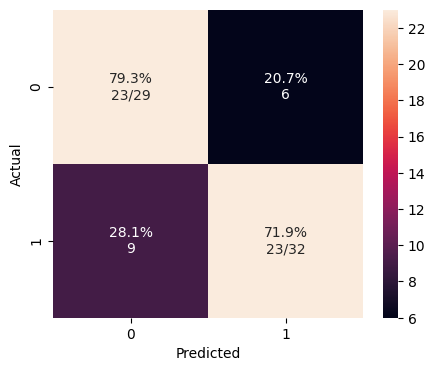

In [27]:
# confusion matrix of QSVC
def cm_analysis(y_true, y_pred, labels, ymap=None, figsize=(5,4)):
    if ymap is not None:
        y_pred = [ymap[yi] for yi in y_pred]
        y_true = [ymap[yi] for yi in y_true]
        labels = [ymap[yi] for yi in labels]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_sum = np.sum(cm, axis=1, keepdims=True)
    cm_perc = cm / cm_sum.astype(float) * 100
    annot = np.empty_like(cm).astype(str)
    nrows, ncols = cm.shape
    for i in range(nrows):
        for j in range(ncols):
            c = cm[i, j]
            p = cm_perc[i, j]
            if i == j:
                s = cm_sum[i][0]
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)
            elif c == 0:
                annot[i, j] = ''
            else:
                annot[i, j] = '%.1f%%\n%d' % (p, c)
    cm = pd.DataFrame(cm, index=labels, columns=labels)
    cm.index.name = 'Actual'
    cm.columns.name = 'Predicted'
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm, annot=annot, fmt='', ax=ax)

cm_analysis(y_test, predicted_y, labels=[0,1], ymap=None, figsize=(5,4))


### QSVC--ROC Curve

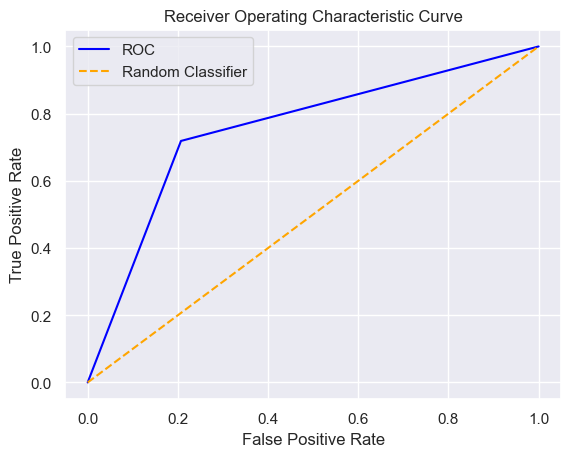

In [28]:
# ROC curve of QSVC
import seaborn as sns
sns.set_theme()



def plot_roc_curve(fper, tper):
    plt.plot(fper, tper, color='blue', label='ROC')
    plt.plot([0, 1], [0, 1], color='orange', linestyle='--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic Curve')
    plt.legend()
    plt.show()
    
fper, tper, thresholds = roc_curve(expected_y, predicted_y)
plot_roc_curve(fper, tper)

## QNN

In [29]:
algorithm_globals.random_seed = 42
sampler = build_sampler(algorithm_globals.random_seed)


In [30]:
X = df[selected_features]
y = df['target'].reset_index(drop=True)

std_scaler = StandardScaler().fit(X)
X = std_scaler.transform(X)

minmax_scaler = MinMaxScaler((0, 1)).fit(X)
X = minmax_scaler.transform(X)

# single train/test split for a stable QNN run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train = np.asarray(X_train, dtype=float)
X_test = np.asarray(X_test, dtype=float)
y_train = np.asarray(y_train, dtype=int)
y_test = np.asarray(y_test, dtype=int)

num_qubits = X_train.shape[1]


In [31]:
# callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

In [32]:
# Classification with a SamplerQNN
# construct feature map
feature_map = build_shared_feature_map(num_qubits)

# construct ansatz
ansatz = build_shared_ansatz(num_qubits)

# construct quantum circuit
qc = QuantumCircuit(num_qubits)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)
qc.measure_all()
qc.decompose()


In [33]:
# parity maps bitstrings to 0 or 1
def parity(x):
    return "{:b}".format(x).count("1") % 2


output_shape = 2  # corresponds to the number of classes, possible outcomes of the (parity) mapping

In [34]:
# =========================
# Construct QNN
# =========================

from qiskit_machine_learning.neural_networks import SamplerQNN

# Backend sampler
sampler = build_sampler(42)

# Parity function
def parity(x):
    return f"{x:b}".count("1") % 2

output_shape = 2  # binary classification

# Construct QNN
circuit_qnn = SamplerQNN(
    circuit=qc,
    sampler=sampler,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    interpret=parity,
    output_shape=output_shape
)

print("QNN constructed successfully")


QNN constructed successfully


In [35]:
# construct classifier
from qiskit.algorithms.optimizers import COBYLA

qnn_optimizer = COBYLA(maxiter=3)

circuit_classifier = NeuralNetworkClassifier(
    neural_network=circuit_qnn,
    optimizer=qnn_optimizer,
    loss='absolute_error'
)


In [36]:
# lightweight QNN training run
qnn_fit_result = circuit_classifier.fit(X_train, y_train)
y_pred = circuit_classifier.predict(X_test)

qnn_accuracy = accuracy_score(y_test, y_pred)
print(f"QNN Accuracy: {qnn_accuracy:.4f}")


QNN Accuracy: 0.5738


# classification report of QNN
expected_y = y_test
predicted_y = y_pred

print(f"QNN Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("Classification report: \n", metrics.classification_report(expected_y, predicted_y))
print("Confusion matrix: \n", metrics.confusion_matrix(expected_y, predicted_y))


In [39]:
# classification report of QNN
expected_y = y_test
predicted_y = y_pred

print(f"QNN Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("Classification report: \n", metrics.classification_report(expected_y, predicted_y))
print("Confusion matrix: \n", metrics.confusion_matrix(expected_y, predicted_y))


QNN Accuracy: 57.38%
Classification report: 
               precision    recall  f1-score   support

           0       0.56      0.36      0.43        28
           1       0.58      0.76      0.66        33

    accuracy                           0.57        61
   macro avg       0.57      0.56      0.55        61
weighted avg       0.57      0.57      0.56        61

Confusion matrix: 
 [[10 18]
 [ 8 25]]


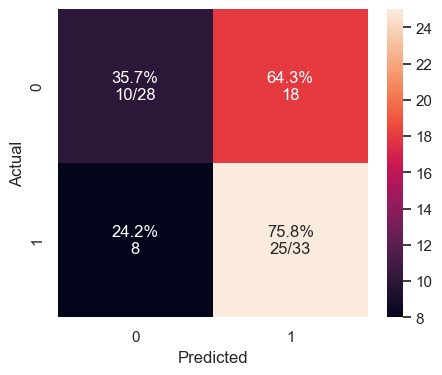

In [40]:
# confusion matrix of QNN
def cm_analysis(y_true, y_pred, labels, ymap=None, figsize=(5,4)):
    if ymap is not None:
        y_pred = [ymap[yi] for yi in y_pred]
        y_true = [ymap[yi] for yi in y_true]
        labels = [ymap[yi] for yi in labels]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_sum = np.sum(cm, axis=1, keepdims=True)
    cm_perc = cm / cm_sum.astype(float) * 100
    annot = np.empty_like(cm).astype(str)
    nrows, ncols = cm.shape
    for i in range(nrows):
        for j in range(ncols):
            c = cm[i, j]
            p = cm_perc[i, j]
            if i == j:
                s = cm_sum[i][0]
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)
            elif c == 0:
                annot[i, j] = ''
            else:
                annot[i, j] = '%.1f%%\n%d' % (p, c)
    cm = pd.DataFrame(cm, index=labels, columns=labels)
    cm.index.name = 'Actual'
    cm.columns.name = 'Predicted'
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm, annot=annot, fmt='', ax=ax)

cm_analysis(y_test, predicted_y, labels=[0,1], ymap=None, figsize=(5,4))


### QNN--ROC Curve

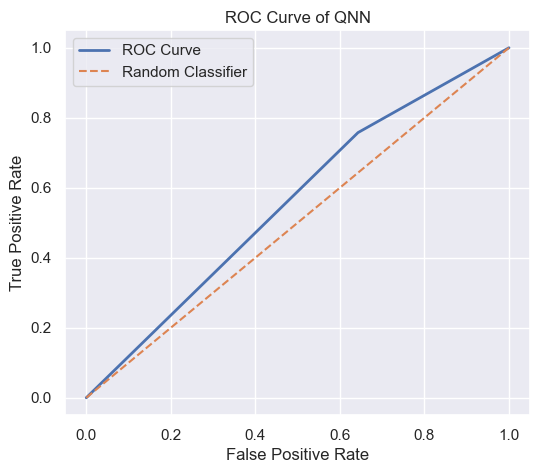

In [41]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC curve of QNN
def plot_roc_curve(fpr, tpr):
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label="ROC Curve", linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve of QNN")
    plt.legend()
    plt.grid(True)
    plt.show()

# expected_y = true labels
# predicted_y = predicted probabilities or labels

fpr, tpr, thresholds = roc_curve(expected_y, predicted_y)
plot_roc_curve(fpr, tpr)


## VQC

In [42]:
X = df[selected_features]
y = df['target']


In [43]:
# ================================
# DATA PREPROCESSING
# ================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Min-Max Scaling to [0,1] (important for quantum encoding)
samples = np.vstack((X_train, X_test))
minmax_scaler = MinMaxScaler((0, 1))
minmax_scaler.fit(samples)

X_train = minmax_scaler.transform(X_train)
X_test = minmax_scaler.transform(X_test)

print('Data preprocessing complete')
print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)


Data preprocessing complete
Train shape: (242, 5)
Test shape : (61, 5)


In [44]:
# ================================
# Ensure NumPy arrays
# ================================

import numpy as np

X_train = np.asarray(X_train, dtype=float)
X_test  = np.asarray(X_test, dtype=float)

y_train = np.asarray(y_train, dtype=int).ravel()
y_test  = np.asarray(y_test, dtype=int).ravel()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Unique labels:", np.unique(y_train))


X_train shape: (242, 5)
y_train shape: (242,)
Unique labels: [0 1]


In [45]:
# ================================
# VQC
# ================================

from qiskit.algorithms.optimizers import SPSA
from qiskit_machine_learning.algorithms import VQC
from qiskit.utils import algorithm_globals
from sklearn.metrics import accuracy_score

# -------------------------
# Parameters
# -------------------------
num_qubits = X_train.shape[1]
algorithm_globals.random_seed = 42

# -------------------------
# Sampler (version-aware)
# -------------------------
sampler = build_sampler(algorithm_globals.random_seed)

# -------------------------
# Feature map & Ansatz
# -------------------------
feature_map = build_shared_feature_map(num_qubits)
ansatz = build_shared_ansatz(num_qubits)

# -------------------------
# Optimizer
# -------------------------
optimizer = SPSA(maxiter=100)

# -------------------------
# VQC Model
# -------------------------
vqc = VQC(
    sampler=sampler,
    num_qubits=num_qubits,
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer
)

# -------------------------
# Train
# -------------------------
vqc.fit(X_train, y_train)

# -------------------------
# Test
# -------------------------
y_pred_vqc = vqc.predict(X_test)

acc = accuracy_score(y_test, y_pred_vqc)
print(f"VQC Test Accuracy: {acc*100:.2f}%")


VQC Test Accuracy: 68.85%


### VOC Performance

In [46]:
#result = vqc.run(quantum_instance)
#print("Quantum accuracy on test set: {0}%".format(round(result['testing_accuracy']*100, 2)))
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.metrics import accuracy_score

y_pred_vqc = vqc.predict(X_test)
acc = accuracy_score(y_test, y_pred_vqc)

print(f"VQC Accuracy: {acc*100:.2f}%")


print("Classification Report:\n")
print(classification_report(y_test, y_pred_vqc))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_vqc))


VQC Accuracy: 68.85%
Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.64      0.65        28
           1       0.71      0.73      0.72        33

    accuracy                           0.69        61
   macro avg       0.69      0.69      0.69        61
weighted avg       0.69      0.69      0.69        61

Confusion Matrix:

[[18 10]
 [ 9 24]]


In [47]:
print(f"y_test shape:      {y_test.shape}")
print(f"predicted_y shape: {len(predicted_y)}")
print(f"X_test shape:      {X_test.shape}")

y_test shape:      (61,)
predicted_y shape: 61
X_test shape:      (61, 5)


### VQC--Confusion Matrix

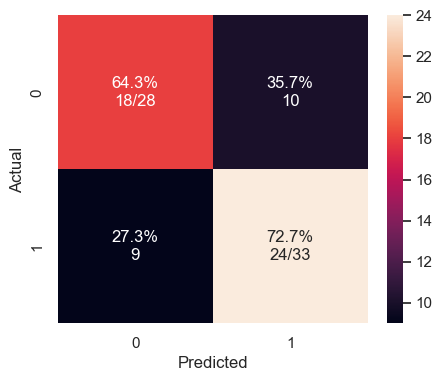

In [48]:
# confusion matrix of VQC
def cm_analysis(y_true, y_pred, labels, ymap=None, figsize=(5,4)):
    if ymap is not None:
        y_pred = [ymap[yi] for yi in y_pred]
        y_true = [ymap[yi] for yi in y_true]
        labels = [ymap[yi] for yi in labels]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_sum = np.sum(cm, axis=1, keepdims=True)
    cm_perc = cm / cm_sum.astype(float) * 100
    annot = np.empty_like(cm).astype(str)
    nrows, ncols = cm.shape
    for i in range(nrows):
        for j in range(ncols):
            c = cm[i, j]
            p = cm_perc[i, j]
            if i == j:
                s = cm_sum[i][0]
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)
            elif c == 0:
                annot[i, j] = ''
            else:
                annot[i, j] = '%.1f%%\n%d' % (p, c)
    cm = pd.DataFrame(cm, index=labels, columns=labels)
    cm.index.name = 'Actual'
    cm.columns.name = 'Predicted'
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm, annot=annot, fmt='', ax=ax)

cm_analysis(y_test, y_pred_vqc, labels=[0,1], ymap=None, figsize=(5,4))


### VQC--ROC Curve

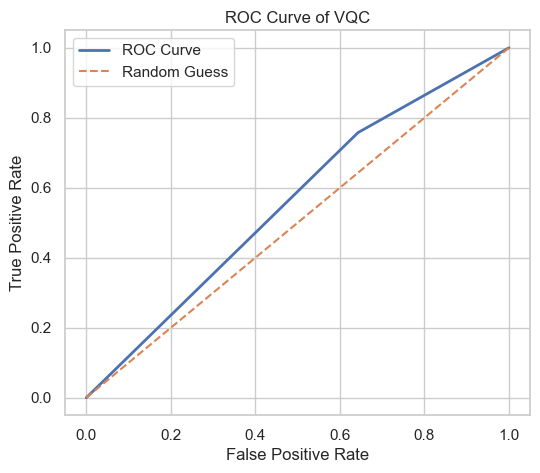

In [49]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn theme (modern & safe)
sns.set_theme(style="whitegrid")

def plot_roc_curve(fpr, tpr):
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label="ROC Curve", linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve of VQC")
    plt.legend()
    plt.show()

# Compute ROC
fpr, tpr, thresholds = roc_curve(expected_y, predicted_y)

# Plot
plot_roc_curve(fpr, tpr)


# Proposed model 

## Bagging-QSVC

In [1]:
import numpy as np
import pandas as pd

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import BaggingClassifier

# qiskit
from qiskit.utils import algorithm_globals
from qiskit.circuit.library import ZZFeatureMap

try:
    from qiskit.circuit.library import zz_feature_map
except ImportError:
    zz_feature_map = None

from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import FidelityQuantumKernel

try:
    from qiskit_machine_learning.kernels import QuantumKernel
except ImportError:
    QuantumKernel = None

try:
    from qiskit_machine_learning.state_fidelities import ComputeUncompute
except ImportError:
    ComputeUncompute = None

import warnings
warnings.filterwarnings('ignore')


In [2]:
data = pd.read_csv('Cleveland Dataset.csv')
df = data.copy()
selected_features = ['ca', 'cp', 'thal', 'exang', 'slope']


def build_shared_feature_map(feature_dimension):
    if zz_feature_map is not None:
        return zz_feature_map(
            feature_dimension=feature_dimension,
            reps=2,
            entanglement='linear'
        )
    return ZZFeatureMap(
        feature_dimension=feature_dimension,
        reps=2,
        entanglement='linear'
    )


def build_quantum_kernel(feature_map, seed=None):
    if ComputeUncompute is not None:
        fidelity = ComputeUncompute(sampler=build_sampler(seed))
        return FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelity)
    if FidelityQuantumKernel is not None:
        return FidelityQuantumKernel(feature_map=feature_map)
    return QuantumKernel(feature_map=feature_map)


In [3]:
X = df[selected_features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

samples = np.append(X_train, X_test, axis=0)
minmax_scaler = MinMaxScaler((0, 1)).fit(samples)
X_train = minmax_scaler.transform(X_train)
X_test = minmax_scaler.transform(X_test)


In [4]:
# number of qubits is equal to the number of features
num_qubits = X_train.shape[1]
# regularization parameter
C = 1000


In [5]:
algorithm_globals.random_seed = 12345

feature_map = build_shared_feature_map(num_qubits)
qkernel = build_quantum_kernel(feature_map, seed=algorithm_globals.random_seed)

qsvc = QSVC(quantum_kernel=qkernel, C=C)


In [6]:
# training
qsvc.fit(X_train,y_train)

# testing
qsvc_score = qsvc.score(X_test, y_test)
print(f"QSVC classification test score: {qsvc_score*100:.2f}%")

QSVC classification test score: 75.41%


In [ ]:
# Pipeline Estimator
pipeline = make_pipeline(MinMaxScaler(), qsvc)

# Instantiate the bagging classifier
bgclassifier = BaggingClassifier(estimator=pipeline, n_estimators=100,
                                 random_state=1, n_jobs=1)

# Fit the bagging classifier
bgclassifier.fit(X_train, y_train)

# Model scores on test and training data
print(f"Model test Score: {bgclassifier.score(X_test, y_test)*100:.2f}%")
print(f"Model training Score: {bgclassifier.score(X_train, y_train)*100:.2f}%")


Model test Score: 80.33%


### Bagging-QSVC performance

In [ ]:
# classification report of Bagging-QSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

expected_y  = y_test
predicted_y = bgclassifier.predict(X_test)

# Accuracy
acc = accuracy_score(expected_y, predicted_y)
print(f"Bagging-QSVC Accuracy: {(acc*100):.2f}%")

# Classification report and confusion matrix
print("Classification report:\n", classification_report(expected_y, predicted_y))
print("Confusion matrix:\n", confusion_matrix(expected_y, predicted_y))


### Bagging-QSVC-- Confusion Matrix

In [ ]:
# confusion matrix of Bagging-QSVC
def cm_analysis(y_true, y_pred, labels, ymap=None, figsize=(5,4)):
    if ymap is not None:
        y_pred = [ymap[yi] for yi in y_pred]
        y_true = [ymap[yi] for yi in y_true]
        labels = [ymap[yi] for yi in labels]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_sum = np.sum(cm, axis=1, keepdims=True)
    cm_perc = cm / cm_sum.astype(float) * 100
    annot = np.empty_like(cm).astype(str)
    nrows, ncols = cm.shape
    for i in range(nrows):
        for j in range(ncols):
            c = cm[i, j]
            p = cm_perc[i, j]
            if i == j:
                s = cm_sum[i][0]
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)
            elif c == 0:
                annot[i, j] = ''
            else:
                annot[i, j] = '%.1f%%\n%d' % (p, c)
    cm = pd.DataFrame(cm, index=labels, columns=labels)
    cm.index.name = 'Actual'
    cm.columns.name = 'Predicted'
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm, annot=annot, fmt='', ax=ax)

cm_analysis(y_test, predicted_y, labels=[0,1], ymap=None, figsize=(5,4))


### Bagging-QSVC--ROC Curve

In [ ]:
# ROC curve of Bagging-QSVC
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

#  Modern seaborn style (safe)
sns.set_theme(style="whitegrid")

def plot_roc_curve(fper, tper):
    plt.figure(figsize=(6, 5))
    plt.plot(fper, tper, label="ROC Curve", linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve of Bagging-QSVC")
    plt.legend()
    plt.show()

# Compute ROC values
fper, tper, thresholds = roc_curve(expected_y, predicted_y)

# Plot ROC
plot_roc_curve(fper, tper)
